# Part 1 - Data Collection

In [1]:
# some preparations
import yfinance as yf
import pandas as pd
import numpy as np
from io import StringIO
import requests
import os

第一步：从维基百科的表格中提取出股票代码列的数据

In [2]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

response = requests.get(
    "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
    headers=headers
)

data = pd.read_html(StringIO(response.text))

df = data[0]
df.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [3]:
tickers = df["Symbol"].str.replace('.', '-', regex=False).tolist()
tickers[: 10]

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

第二步：用股票代码 `tickers` 列作为匹配源获取2015年1月-2025年6月的对应股票数据信息

In [4]:
# 【注意！】由于我从国内下载不稳定，这里下载时我写了个函数用以重复下载之前下载失败的数据。理论上你那边用下面这条注释语句就能跑，你可以试试：
#  raw = yf.download(tickers, start="2015-01-01", end="2025-06-30", progress=True, auto_adjust=False)
def download_sp500(tickers, start="2015-01-01", end="2025-06-30"):
    # 第一次批量下载
    raw = yf.download(tickers, start=start, end=end, progress=True, auto_adjust=False)
    
    # 找出失败的（整列全是NaN）
    all_tickers = raw.columns.get_level_values("Ticker").unique().tolist()
    failed = [t for t in all_tickers if raw.xs(t, level="Ticker", axis=1).isna().all().all()]
    missing = [t for t in tickers if t not in all_tickers]
    retry = list(set(failed + missing))
    
    print(f"第一次下载: 成功 {len(tickers)-len(retry)} 只, 失败 {len(retry)} 只")
    
    # 对失败的逐只重试一次
    if retry:
        for ticker in retry:
            try:
                tmp = yf.download(ticker, start=start, end=end, progress=False)
                if not tmp.empty:
                    tmp.columns = pd.MultiIndex.from_product([[c for c in tmp.columns], [ticker]], names=["Price", "Ticker"])
                    raw = pd.concat([raw, tmp], axis=1)
                    print(f"{ticker} 重试成功")
            except:
                print(f"{ticker} 放弃")
    
    # 去重列
    raw = raw.loc[:, ~raw.columns.duplicated()]
    return raw

raw = download_sp500(tickers)
raw.to_parquet("../data/raw_data.parquet")
print(f"保存成功, shape: {raw.shape}")

[**********************76%***********            ]  380 of 503 completed$Q: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-06-30) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1751256000")
[*********************100%***********************]  503 of 503 completed

1 Failed download:
['Q']: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-06-30) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1751256000")


第一次下载: 成功 502 只, 失败 1 只


$Q: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-06-30) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1751256000")

1 Failed download:
['Q']: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-06-30) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1751256000")


保存成功, shape: (2637, 3018)


我这里反复试了多次，这个代码是Q的怎么也提取不了。似乎不在yf库中。我就不考虑它了。你试试你行不行。不行就算了。

第三步：数据清洗

In [5]:
# 去掉多重column
stocks = raw.stack(level='Ticker').reset_index()
print(stocks.shape)
stocks.head()

(1326411, 8)


Price,Date,Ticker,Adj Close,Close,High,Low,Open,Volume
0,2015-01-02,A,37.054722,40.560001,41.310001,40.369999,41.180000,1529200.0
1,2015-01-02,AAPL,24.214899,27.332500,27.860001,26.837500,27.847500,212818400.0
2,2015-01-02,ABBV,41.755470,65.889999,66.400002,65.440002,65.440002,5086100.0
3,2015-01-02,ABNB,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-02,ABT,36.235119,44.900002,45.450001,44.639999,45.250000,3216600.0


这里这个ABNB数据是NaN不要担心，是正常的。我问AI说，ABNB这个公司在2015年这个时间段还没上市，所以是合理的。

In [6]:
# 去掉index列的column name
stocks.columns.name = None
# 去掉有NaN值的相关行数据
stocks = stocks.dropna(subset=['Close'])
# 跟pdf示例保持一致，将Ticker小写
stocks['Ticker'] = stocks['Ticker'].str.lower()
stocks.head()

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume
0,2015-01-02,a,37.054722,40.560001,41.310001,40.369999,41.180000,1529200.0
1,2015-01-02,aapl,24.214899,27.332500,27.860001,26.837500,27.847500,212818400.0
2,2015-01-02,abbv,41.755470,65.889999,66.400002,65.440002,65.440002,5086100.0
4,2015-01-02,abt,36.235119,44.900002,45.450001,44.639999,45.250000,3216600.0
5,2015-01-02,acgl,18.539352,19.496668,19.860001,19.426666,19.733334,1101600.0


In [7]:
# 股票池筛选：科技行业 + 流动性 Top 50

import yfinance as yf

# 步骤1：获取每只股票的行业信息
# 从已有的 tickers 列表中批量查询 sector
print("正在获取行业信息（需要1-2分钟）...")

sector_map = {}
for ticker in tickers:
    try:
        info = yf.Ticker(ticker).info
        sector_map[ticker.lower()] = info.get('sector', 'Unknown')
    except:
        sector_map[ticker.lower()] = 'Unknown'

# 步骤2：筛出科技行业的股票代码
tech_tickers = [t for t, s in sector_map.items() if s == 'Technology']
print(f"科技行业股票数量: {len(tech_tickers)}")

# 步骤3：先把 stocks 裁剪到科技行业
stocks = stocks[stocks['Ticker'].isin(tech_tickers)].copy()
print(f"筛选科技行业后数据量: {stocks.shape}")

# 步骤4：计算每只股票的年均日成交额（流动性指标）
# 用收盘价 × 成交量，取全部时间的均值
stocks['dollar_volume'] = stocks['Close'] * stocks['Volume']
liquidity = (
    stocks.groupby('Ticker')['dollar_volume']
    .mean()
    .sort_values(ascending=False)
)

# 步骤5：取流动性 Top 50
top50_tickers = liquidity.head(50).index.tolist()
stocks = stocks[stocks['Ticker'].isin(top50_tickers)].copy()
stocks = stocks.drop(columns=['dollar_volume'])  # 清理临时列

print(f"\n最终股票池: {len(top50_tickers)} 只股票")
print(f"最终数据量: {stocks.shape}")
print(f"股票列表: {sorted(top50_tickers)}")

正在获取行业信息（需要1-2分钟）...
科技行业股票数量: 82
筛选科技行业后数据量: (204939, 8)

最终股票池: 50 只股票
最终数据量: (126174, 8)
股票列表: ['aapl', 'acn', 'adbe', 'adi', 'adp', 'adsk', 'amat', 'amd', 'anet', 'aph', 'avgo', 'cdns', 'crm', 'crwd', 'csco', 'ctsh', 'ddog', 'dell', 'fis', 'fslr', 'ftnt', 'glw', 'hpe', 'hpq', 'ibm', 'intc', 'intu', 'klac', 'lrcx', 'mchp', 'msft', 'mu', 'now', 'nvda', 'nxpi', 'on', 'orcl', 'panw', 'pltr', 'qcom', 'rop', 'smci', 'snps', 'stx', 'swks', 'txn', 'uber', 'wday', 'wdc', 'xyz']


第四步：计算真实收益率

In [8]:
# 所有股票数据的第一天的收益率就应该是NaN，不用怀疑
stocks['Return'] = stocks.groupby('Ticker')['Adj Close'].pct_change()
stocks[stocks['Ticker'] == 'aapl'].head(5)

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Return
1,2015-01-02,aapl,24.214899,27.332500,27.860001,26.837500,27.847500,212818400.0,NaN
504,2015-01-05,aapl,23.532719,26.562500,27.162500,26.352501,27.072500,257142000.0,-0.028172
1007,2015-01-06,aapl,23.534933,26.565001,26.857500,26.157499,26.635000,263188400.0,0.000094
1510,2015-01-07,aapl,23.864941,26.937500,27.049999,26.674999,26.799999,160423600.0,0.014022
2013,2015-01-08,aapl,24.781897,27.972500,28.037500,27.174999,27.307501,237458000.0,0.038423


# Part 2 - Alpha Generation & Evaluatioon

In [10]:
from numpy import abs
from numpy import log
from numpy import sign
from scipy.stats import rankdata

In [11]:
stocks['VWAP'] = (stocks['High'] + stocks['Low'] + stocks['Close']) / 3
stocks['adv20'] = stocks.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(20).mean())
stocks.head()

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Return,VWAP,adv20
1,2015-01-02,aapl,24.214899,27.332500,27.860001,26.837500,27.847500,212818400.0,NaN,27.343334,NaN
6,2015-01-02,acn,74.252617,88.839996,90.089996,88.430000,89.669998,2021300.0,NaN,89.119998,NaN
7,2015-01-02,adbe,72.339996,72.339996,73.199997,71.889999,72.699997,2349200.0,NaN,72.476664,NaN
8,2015-01-02,adi,44.216049,55.540001,56.250000,54.970001,55.680000,1323200.0,NaN,55.586667,NaN
10,2015-01-02,adp,65.562584,83.290001,84.180000,82.519997,82.980003,1866600.0,NaN,83.329999,NaN


In [12]:
import sys
sys.path.append("../src")

from alpha_functions import *

In [13]:
# ============ 因子计算 ============

# --- 短期反转 ---
stocks['alpha_rev5'] = -1 * stocks.groupby('Ticker')['Adj Close'].pct_change(5)
stocks['alpha_rev1'] = -1 * stocks['Return']

# --- 中期动量 ---
stocks['alpha_mom20'] = stocks.groupby('Ticker')['Adj Close'].pct_change(20)
ret_60 = stocks.groupby('Ticker')['Adj Close'].pct_change(60)
ret_5  = stocks.groupby('Ticker')['Adj Close'].pct_change(5)
stocks['alpha_mom60_skip5'] = ret_60 - ret_5

# --- 波动率 ---
stocks['alpha_vol20'] = -1 * stocks.groupby('Ticker')['Return'].transform(
    lambda x: x.rolling(20).std()
)

# --- 量价背离 ---
stocks['alpha_vp_corr'] = stocks.groupby('Ticker').apply(
    lambda x: x['Return'].rolling(10).corr(x['Volume'].pct_change())
).reset_index(level=0, drop=True)

# --- 流动性 ---
vol_5  = stocks.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(5).mean())
vol_20 = stocks.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(20).mean())
stocks['alpha_vol_ratio'] = vol_5 / vol_20

# --- VWAP偏离 ---
stocks['alpha_vwap_dev'] = (stocks['Close'] - stocks['VWAP']) / stocks['VWAP']

# --- 价格形态 ---
stocks['alpha_range'] = stocks.groupby('Ticker').apply(
    lambda x: ((x['High'] - x['Low']) / x['Close']).rolling(10).mean()
).reset_index(level=0, drop=True)

In [14]:
# --- 慢因子 ---
# 60日波动率（低波动率异象，长周期版本）
stocks['alpha_vol60'] = -1 * stocks.groupby('Ticker')['Return'].transform(
    lambda x: x.rolling(60).std()
)

# 120日动量（跳过最近20天，避免短期反转干扰）
ret_120 = stocks.groupby('Ticker')['Adj Close'].pct_change(120)
ret_20 = stocks.groupby('Ticker')['Adj Close'].pct_change(20)
stocks['alpha_mom120_skip20'] = ret_120 - ret_20

# 成交量长期趋势（60日均量 vs 120日均量）
vol_60 = stocks.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(60).mean())
vol_120 = stocks.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(120).mean())
stocks['alpha_vol_trend'] = vol_60 / vol_120

# 波动率变化趋势（近期波动率 vs 长期波动率）
vol_short = stocks.groupby('Ticker')['Return'].transform(lambda x: x.rolling(20).std())
vol_long = stocks.groupby('Ticker')['Return'].transform(lambda x: x.rolling(60).std())
stocks['alpha_vol_change'] = -1 * (vol_short / vol_long)

In [15]:
stocks[stocks['Ticker'] == 'aapl'].head()

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Return,VWAP,...,alpha_mom60_skip5,alpha_vol20,alpha_vp_corr,alpha_vol_ratio,alpha_vwap_dev,alpha_range,alpha_vol60,alpha_mom120_skip20,alpha_vol_trend,alpha_vol_change
1,2015-01-02,aapl,24.214899,27.332500,27.860001,26.837500,27.847500,212818400.0,NaN,27.343334,...,NaN,NaN,NaN,NaN,-0.000396,NaN,NaN,NaN,NaN,NaN
504,2015-01-05,aapl,23.532719,26.562500,27.162500,26.352501,27.072500,257142000.0,-0.028172,26.692500,...,NaN,NaN,NaN,NaN,-0.004870,NaN,NaN,NaN,NaN,NaN
1007,2015-01-06,aapl,23.534933,26.565001,26.857500,26.157499,26.635000,263188400.0,0.000094,26.526667,...,NaN,NaN,NaN,NaN,0.001445,NaN,NaN,NaN,NaN,NaN
1510,2015-01-07,aapl,23.864941,26.937500,27.049999,26.674999,26.799999,160423600.0,0.014022,26.887499,...,NaN,NaN,NaN,NaN,0.001860,NaN,NaN,NaN,NaN,NaN
2013,2015-01-08,aapl,24.781897,27.972500,28.037500,27.174999,27.307501,237458000.0,0.038423,27.728333,...,NaN,NaN,NaN,NaN,0.008806,NaN,NaN,NaN,NaN,NaN


In [16]:
alpha_cols = ['alpha_rev5', 'alpha_rev1', 'alpha_mom20', 'alpha_mom60_skip5',
              'alpha_vol20', 'alpha_vp_corr', 'alpha_vol_ratio', 
              'alpha_vwap_dev', 'alpha_range', 'alpha_vol60', 
              'alpha_mom120_skip20', 'alpha_vol_trend', 'alpha_vol_change']

def winsorize_mad(series, n_mad=3):
    median = series.median()
    mad = (series - median).abs().median() * 1.4826
    lower = median - n_mad * mad
    upper = median + n_mad * mad
    return series.clip(lower, upper)

for col in alpha_cols:
    # 第一步：每天cross-sectional去极值
    stocks[col] = stocks.groupby('Date')[col].transform(winsorize_mad)
    
    # 第二步：TS z-score（每只股票用自己过去60天的均值和标准差标准化）
    stocks[col] = stocks.groupby('Ticker')[col].transform(
        lambda x: (x - x.rolling(60).mean()) / x.rolling(60).std()
    )
    
    # 第三步：再做一次cross-sectional去极值（TS之后可能产生新的极端值）
    stocks[col] = stocks.groupby('Date')[col].transform(winsorize_mad)
    
    # 第四步：CS z-score（每天对所有股票标准化）
    stocks[col] = stocks.groupby('Date')[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

stocks[stocks['Ticker'] == 'aapl'].head(10)

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Return,VWAP,...,alpha_mom60_skip5,alpha_vol20,alpha_vp_corr,alpha_vol_ratio,alpha_vwap_dev,alpha_range,alpha_vol60,alpha_mom120_skip20,alpha_vol_trend,alpha_vol_change
1,2015-01-02,aapl,24.214899,27.332500,27.860001,26.837500,27.847500,212818400.0,NaN,27.343334,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
504,2015-01-05,aapl,23.532719,26.562500,27.162500,26.352501,27.072500,257142000.0,-0.028172,26.692500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1007,2015-01-06,aapl,23.534933,26.565001,26.857500,26.157499,26.635000,263188400.0,0.000094,26.526667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1510,2015-01-07,aapl,23.864941,26.937500,27.049999,26.674999,26.799999,160423600.0,0.014022,26.887499,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013,2015-01-08,aapl,24.781897,27.972500,28.037500,27.174999,27.307501,237458000.0,0.038423,27.728333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2516,2015-01-09,aapl,24.808464,28.002501,28.312500,27.552500,28.167500,214798000.0,0.001072,27.955833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3019,2015-01-12,aapl,24.197170,27.312500,28.157499,27.200001,28.150000,198603200.0,-0.024641,27.556667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3522,2015-01-13,aapl,24.412022,27.555000,28.200001,27.227501,27.857500,268367600.0,0.008879,27.660834,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4025,2015-01-14,aapl,24.318987,27.450001,27.622499,27.125000,27.260000,195826400.0,-0.003811,27.399167,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4528,2015-01-15,aapl,23.658966,26.705000,27.514999,26.665001,27.500000,240056000.0,-0.027140,26.961667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


分析

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

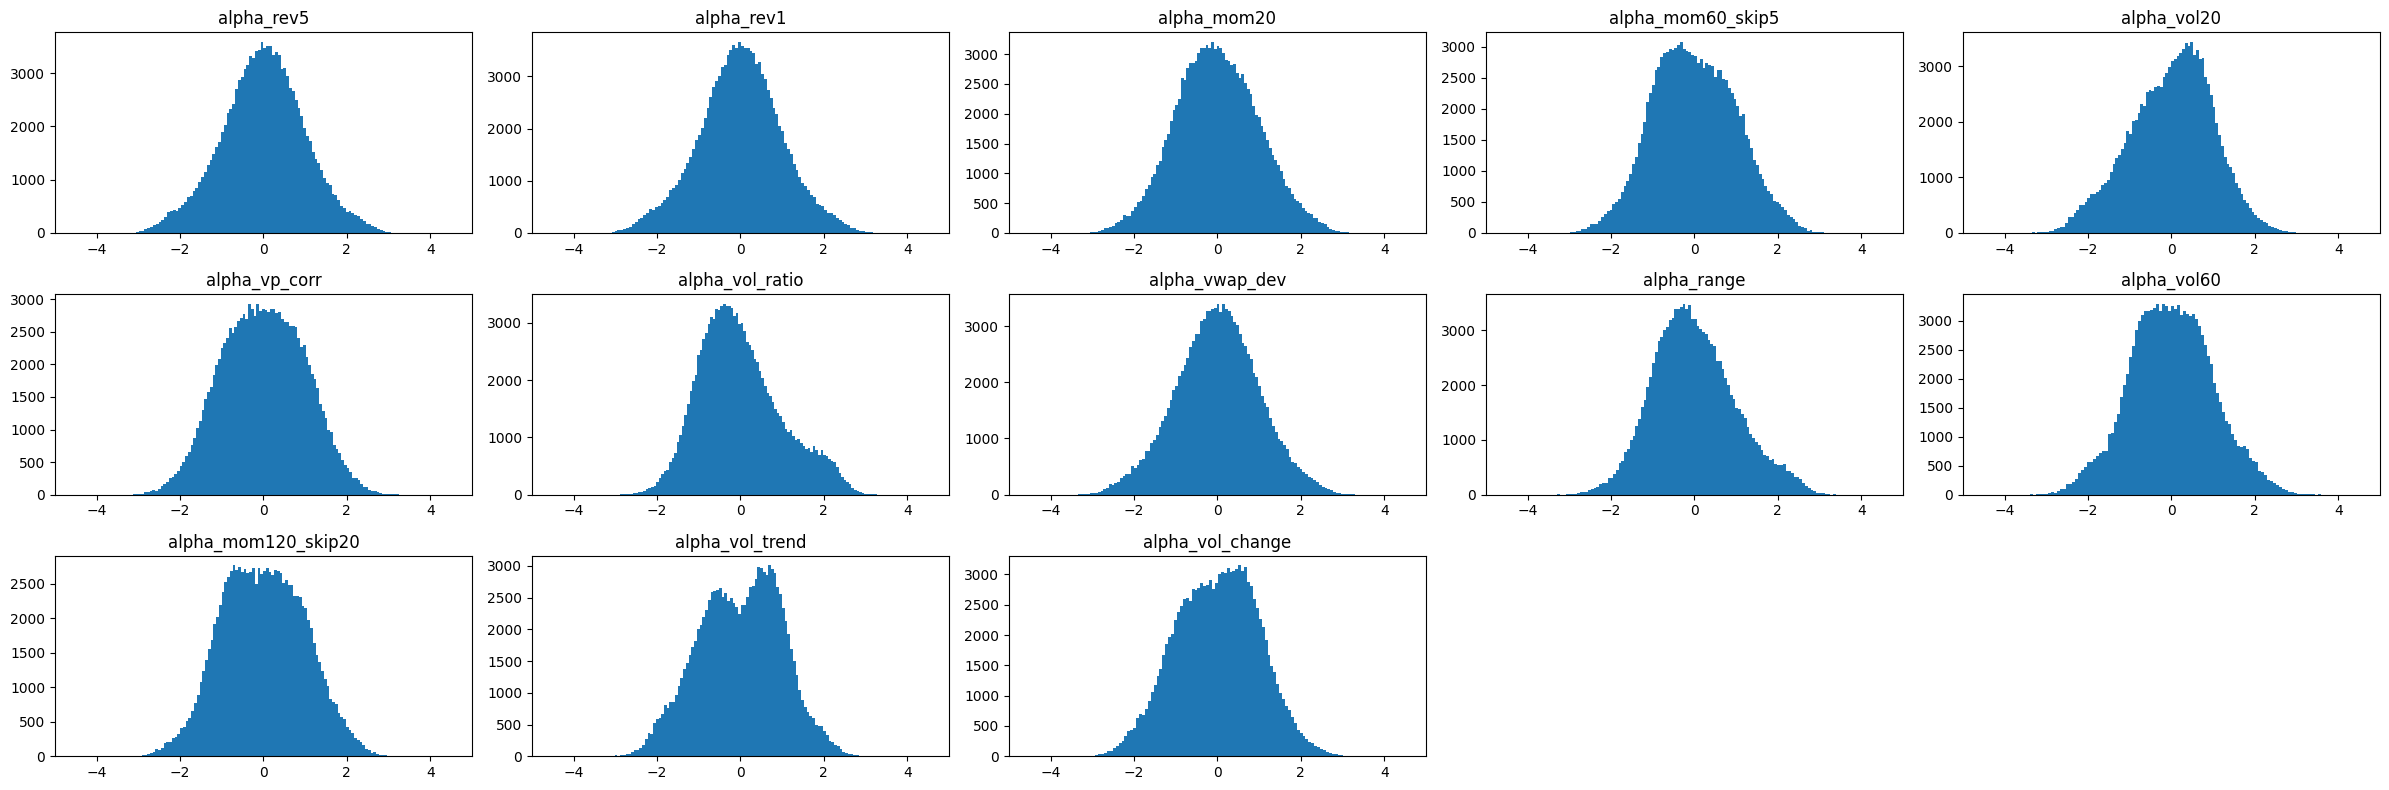

,alpha_rev5,alpha_rev1,alpha_mom20,alpha_mom60_skip5,alpha_vol20,alpha_vp_corr,alpha_vol_ratio,alpha_vwap_dev,alpha_range,alpha_vol60,alpha_mom120_skip20,alpha_vol_trend,alpha_vol_change
count,122974.0000,123174.0000,122224.0000,120224.0000,122224.0000,122723.0000,122274.0000,123224.0000,122774.0000,120224.0000,117224.0000,117274.0000,120224.0000
mean,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000
std,0.9895,0.9895,0.9895,0.9895,0.9895,0.9895,0.9895,0.9895,0.9895,0.9895,0.9895,0.9895,0.9895
min,-3.3960,-3.5692,-3.2536,-3.3850,-3.3462,-3.3177,-2.8822,-3.3309,-3.2830,-3.5977,-3.1863,-3.4104,-3.4879
25%,-0.6392,-0.6339,-0.6925,-0.7260,-0.6692,-0.7297,-0.7135,-0.6559,-0.6967,-0.6892,-0.7400,-0.7235,-0.7227
50%,0.0125,0.0062,-0.0282,-0.0392,0.0832,-0.0021,-0.1302,0.0092,-0.0808,-0.0165,-0.0177,0.0510,0.0317
75%,0.6512,0.6409,0.6791,0.7144,0.7034,0.7296,0.5938,0.6611,0.6287,0.6704,0.7255,0.7464,0.7162
max,3.3995,3.3210,3.3459,3.3681,3.3238,3.2393,3.2758,3.2961,3.3852,3.5746,3.4328,3.1662,3.5098


In [18]:
fig, axes = plt.subplots(3, 5, figsize=(24, 8))  # 分布图
axes = axes.flatten()

alpha_cols = ['alpha_rev5', 'alpha_rev1', 'alpha_mom20', 'alpha_mom60_skip5',
              'alpha_vol20', 'alpha_vp_corr', 'alpha_vol_ratio', 
              'alpha_vwap_dev', 'alpha_range', 'alpha_vol60', 
              'alpha_mom120_skip20', 'alpha_vol_trend', 'alpha_vol_change']

for i, col in enumerate(alpha_cols):
    data = stocks[col].dropna()
    axes[i].hist(data, bins=100, edgecolor='none')
    axes[i].set_title(col)
    axes[i].set_xlim(-5, 5)

for j in range(len(alpha_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../results/alpha_distributions.png', dpi=150)
plt.show()

# 统计量
stocks[alpha_cols].describe().round(4)

In [19]:
from scipy.stats import skew, kurtosis

eda_stats = pd.DataFrame({
    'Mean': stocks[alpha_cols].mean(),
    'Std': stocks[alpha_cols].std(),
    'Skewness': stocks[alpha_cols].apply(lambda x: skew(x, nan_policy='omit')),
    'Kurtosis': stocks[alpha_cols].apply(lambda x: kurtosis(x, nan_policy='omit')),
    'Min': stocks[alpha_cols].min(),
    'Max': stocks[alpha_cols].max(),
})
print(eda_stats.round(4))

                     Mean     Std  Skewness  Kurtosis     Min     Max
alpha_rev5           -0.0  0.9895   -0.0462   -0.0080 -3.3960  3.3995
alpha_rev1            0.0  0.9895   -0.0301    0.0267 -3.5692  3.3210
alpha_mom20          -0.0  0.9895    0.0889   -0.2204 -3.2536  3.3459
alpha_mom60_skip5     0.0  0.9895    0.0975   -0.3761 -3.3850  3.3681
alpha_vol20          -0.0  0.9895   -0.2444   -0.2264 -3.3462  3.3238
alpha_vp_corr         0.0  0.9895    0.0032   -0.4659 -3.3177  3.2393
alpha_vol_ratio      -0.0  0.9895    0.4917   -0.1500 -2.8822  3.2758
alpha_vwap_dev       -0.0  0.9895   -0.0279   -0.0803 -3.3309  3.2961
alpha_range          -0.0  0.9895    0.3087   -0.0748 -3.2830  3.3852
alpha_vol60           0.0  0.9895    0.0619   -0.1423 -3.5977  3.5746
alpha_mom120_skip20  -0.0  0.9895    0.0597   -0.4458 -3.1863  3.4328
alpha_vol_trend      -0.0  0.9895   -0.1148   -0.4989 -3.4104  3.1662
alpha_vol_change     -0.0  0.9895   -0.0479   -0.3792 -3.4879  3.5098


In [20]:
stocks['Return_next'] = stocks.groupby('Ticker')['Adj Close'].pct_change(5).shift(-5)

In [21]:
# 每天计算每个alpha和明天收益的相关系数
ic_results = {}

for col in alpha_cols:
    daily_ic = stocks.groupby('Date').apply(
        lambda x: spearmanr(
            x[[col, 'Return_next']].dropna()[col],
            x[[col, 'Return_next']].dropna()['Return_next']
        )[0]
    )
    ic_results[col] = {
        'IC Mean': daily_ic.mean(),
        'IC Std': daily_ic.std(),
        'ICIR': daily_ic.mean() / daily_ic.std(),
        'IC > 0 (%)': (daily_ic > 0).mean() * 100
    }

ic_df = pd.DataFrame(ic_results).T.round(4)
print(ic_df)

                     IC Mean  IC Std    ICIR  IC > 0 (%)
alpha_rev5            0.0098  0.1469  0.0670     50.7016
alpha_rev1            0.0050  0.1461  0.0341     51.1945
alpha_mom20          -0.0042  0.1448 -0.0290     46.6439
alpha_mom60_skip5    -0.0007  0.1478 -0.0046     46.4922
alpha_vol20           0.0003  0.1537  0.0018     48.5021
alpha_vp_corr        -0.0042  0.1409 -0.0300     48.2746
alpha_vol_ratio      -0.0029  0.1487 -0.0192     46.9094
alpha_vwap_dev       -0.0056  0.1496 -0.0376     47.0990
alpha_range          -0.0035  0.1525 -0.0229     47.8953
alpha_vol60          -0.0073  0.1467 -0.0495     45.6579
alpha_mom120_skip20  -0.0057  0.1510 -0.0380     45.3166
alpha_vol_trend      -0.0080  0.1511 -0.0532     44.0273
alpha_vol_change      0.0066  0.1521  0.0431     49.7535


根据首轮IC评估信息调整因子。

In [24]:
# 把IC为负的因子翻转方向
stocks['alpha_mom20'] = -1 * stocks['alpha_mom20']  # 翻转成反转因子
stocks['alpha_vwap_dev'] = -1 * stocks['alpha_vwap_dev']  # 翻转
stocks['alpha_vp_corr'] = -1 * stocks['alpha_vp_corr']  # 翻转
stocks['alpha_range'] = -1 * stocks['alpha_range']  # 翻转
stocks['alpha_vol60'] = -1 * stocks['alpha_vol60']  # 翻转
stocks['alpha_mom120_skip20'] = -1 * stocks['alpha_mom120_skip20']  # 翻转
stocks['alpha_vol_trend'] = -1 * stocks['alpha_vol_trend']  # 翻转

In [25]:
# 重新计算修改的因子的IC结果
ic_results = {}

for col in ['alpha_mom20', 'alpha_vwap_dev', 'alpha_vp_corr', 'alpha_range', 'alpha_vol60', 'alpha_mom120_skip20', 'alpha_vol_trend']:
    daily_ic = stocks.groupby('Date').apply(
        lambda x: spearmanr(
            x[[col, 'Return_next']].dropna()[col],
            x[[col, 'Return_next']].dropna()['Return_next']
        )[0]
    )
    ic_results[col] = {
        'IC Mean': daily_ic.mean(),
        'IC Std': daily_ic.std(),
        'ICIR': daily_ic.mean() / daily_ic.std(),
        'IC > 0 (%)': (daily_ic > 0).mean() * 100
    }

ic_df = pd.DataFrame(ic_results).T.round(4)
print(ic_df)

                     IC Mean  IC Std    ICIR  IC > 0 (%)
alpha_mom20          -0.0042  0.1448 -0.0290     46.6439
alpha_vwap_dev       -0.0056  0.1496 -0.0376     47.0990
alpha_vp_corr         0.0042  0.1409  0.0300     49.1088
alpha_range           0.0035  0.1525  0.0229     49.4881
alpha_vol60           0.0073  0.1467  0.0495     49.8294
alpha_mom120_skip20   0.0057  0.1510  0.0380     47.8953
alpha_vol_trend       0.0080  0.1511  0.0532     49.1847


           alpha_rev5  alpha_rev1  alpha_mom20  alpha_mom60_skip5  \
Q1 (Low)     0.004457    0.005098     0.005232           0.005284   
Q2           0.005070    0.004943     0.004860           0.004804   
Q3           0.005513    0.004484     0.005023           0.005304   
Q4           0.005193    0.005532     0.005341           0.004892   
Q5 (High)    0.004977    0.005086     0.004704           0.005086   

           alpha_vol20  alpha_vp_corr  alpha_vol_ratio  alpha_vwap_dev  \
Q1 (Low)      0.004895       0.004936         0.005679        0.005083   
Q2            0.005493       0.005051         0.004700        0.005122   
Q3            0.004339       0.004599         0.005180        0.004859   
Q4            0.005135       0.005131         0.004972        0.005264   
Q5 (High)     0.005304       0.005420         0.004602        0.004779   

           alpha_range  alpha_vol60  alpha_mom120_skip20  alpha_vol_trend  \
Q1 (Low)      0.004539     0.004628             0.004714       

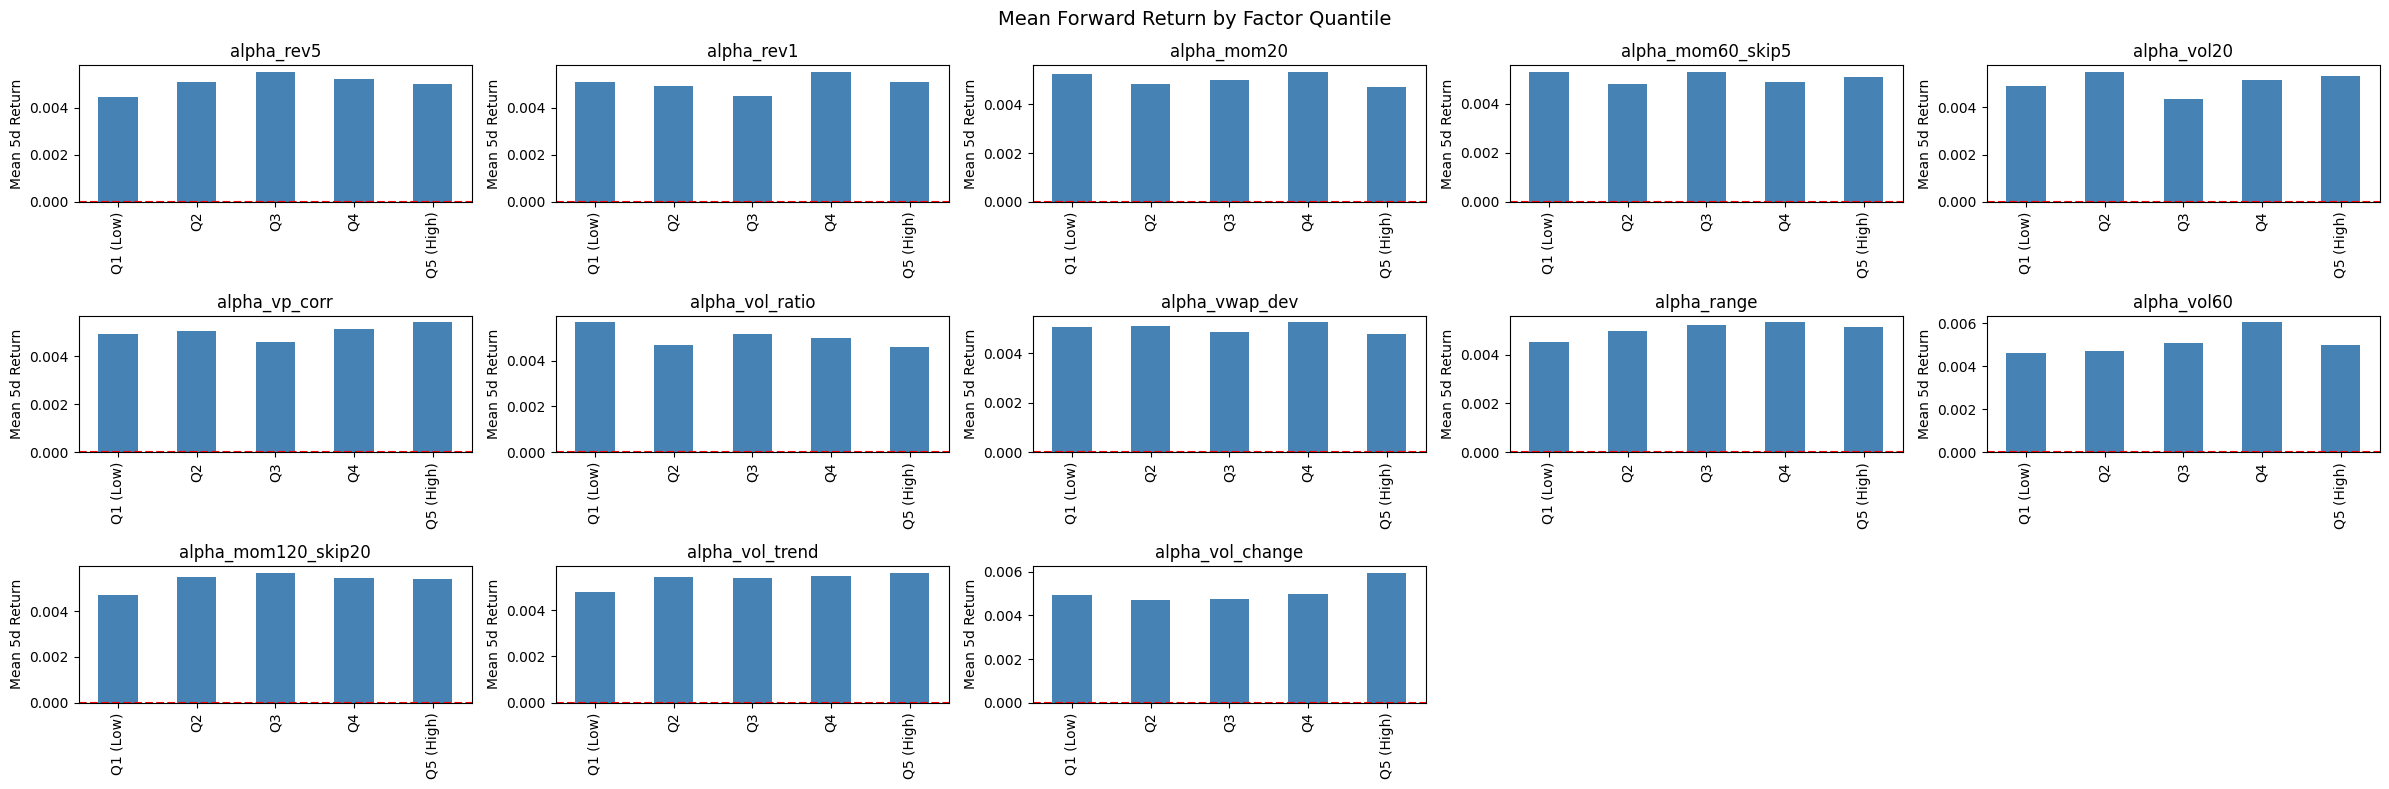

In [26]:
n_quantiles = 5

for col in alpha_cols:
    stocks[f'{col}_q'] = stocks.groupby('Date')[col].transform(
        lambda x: pd.qcut(x, n_quantiles, labels=False, duplicates='drop')
    )

quantile_returns = {}
for col in alpha_cols:
    qr = stocks.groupby(f'{col}_q')['Return_next'].mean()
    quantile_returns[col] = qr

qr_df = pd.DataFrame(quantile_returns)
qr_df.index = [f'Q{i+1} (Low)' if i == 0 
               else f'Q{i+1} (High)' if i == n_quantiles-1 
               else f'Q{i+1}' for i in range(len(qr_df))]
print(qr_df.round(6))

fig, axes = plt.subplots(3, 5, figsize=(24, 8))
axes = axes.flatten()
for i, col in enumerate(alpha_cols):
    qr_df[col].plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Mean 5d Return')
    axes[i].axhline(0, color='red', linestyle='--')
for j in range(len(alpha_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Mean Forward Return by Factor Quantile', fontsize=14)
plt.tight_layout()
plt.savefig('../results/quantile_returns.png', dpi=150)
plt.show()

计算因子之间的平均cross-sectional相关系数，作因子取舍。

In [27]:
# 每天算一次因子之间的相关矩阵，然后取时间平均
corr_daily = stocks.groupby('Date')[alpha_cols].corr()
avg_corr = corr_daily.groupby(level=1).mean()
print(avg_corr.round(3))

                     alpha_rev5  alpha_rev1  alpha_mom20  alpha_mom60_skip5  \
alpha_mom120_skip20      -0.117      -0.047        0.271             -0.176   
alpha_mom20              -0.470      -0.195        1.000              0.298   
alpha_mom60_skip5         0.144       0.065        0.298              1.000   
alpha_range              -0.008      -0.000        0.063              0.083   
alpha_rev1                0.409       1.000       -0.195              0.065   
alpha_rev5                1.000       0.409       -0.470              0.144   
alpha_vol20               0.003       0.002        0.021              0.066   
alpha_vol60              -0.011      -0.001        0.003             -0.061   
alpha_vol_change         -0.005       0.000        0.026              0.039   
alpha_vol_ratio          -0.015      -0.005       -0.020             -0.014   
alpha_vol_trend           0.012       0.003       -0.024              0.029   
alpha_vp_corr             0.344       0.102       -0

In [28]:
# 试试不同的forward return
for days in [1, 3, 5, 10, 20]:
    stocks[f'ret_fwd_{days}'] = stocks.groupby('Ticker')['Adj Close'].pct_change(days).shift(-days)
    
    for col in alpha_cols:
        ic = stocks.groupby('Date').apply(
            lambda x, c=col, d=days: spearmanr(
                x[[c, f'ret_fwd_{d}']].dropna()[c],
                x[[c, f'ret_fwd_{d}']].dropna()[f'ret_fwd_{d}']
            )[0]
        )
        print(f"{col} -> {days}d fwd: IC={ic.mean():.4f}, ICIR={ic.mean()/ic.std():.4f}")

alpha_rev5 -> 1d fwd: IC=-0.0025, ICIR=-0.0545
alpha_rev1 -> 1d fwd: IC=-0.0054, ICIR=-0.1175
alpha_mom20 -> 1d fwd: IC=-0.0017, ICIR=-0.0352
alpha_mom60_skip5 -> 1d fwd: IC=0.0003, ICIR=0.0062
alpha_vol20 -> 1d fwd: IC=-0.0003, ICIR=-0.0054
alpha_vp_corr -> 1d fwd: IC=0.0006, ICIR=0.0127
alpha_vol_ratio -> 1d fwd: IC=-0.0012, ICIR=-0.0268
alpha_vwap_dev -> 1d fwd: IC=-0.0048, ICIR=-0.1053
alpha_range -> 1d fwd: IC=0.0003, ICIR=0.0075
alpha_vol60 -> 1d fwd: IC=0.0011, ICIR=0.0239
alpha_mom120_skip20 -> 1d fwd: IC=0.0007, ICIR=0.0158
alpha_vol_trend -> 1d fwd: IC=-0.0000, ICIR=-0.0006
alpha_vol_change -> 1d fwd: IC=0.0006, ICIR=0.0118
alpha_rev5 -> 3d fwd: IC=0.0003, ICIR=0.0074
alpha_rev1 -> 3d fwd: IC=-0.0006, ICIR=-0.0146
alpha_mom20 -> 3d fwd: IC=0.0006, ICIR=0.0145
alpha_mom60_skip5 -> 3d fwd: IC=0.0020, ICIR=0.0443
alpha_vol20 -> 3d fwd: IC=-0.0003, ICIR=-0.0067
alpha_vp_corr -> 3d fwd: IC=-0.0010, ICIR=-0.0217
alpha_vol_ratio -> 3d fwd: IC=-0.0019, ICIR=-0.0415
alpha_vwap_dev -> 

In [28]:
# 等权组合因子
stocks['alpha_combined'] = stocks[alpha_cols].mean(axis=1)

# 算组合因子的IC
daily_ic_combined = stocks.groupby('Date').apply(
    lambda x: spearmanr(
        x[['alpha_combined', 'Return_next']].dropna()['alpha_combined'],
        x[['alpha_combined', 'Return_next']].dropna()['Return_next']
    )[0]
)
print(f"Combined IC Mean: {daily_ic_combined.mean():.4f}")
print(f"Combined ICIR: {daily_ic_combined.mean()/daily_ic_combined.std():.4f}")

Combined IC Mean: 0.0097
Combined ICIR: 0.0665


根据上述信息，考量删去如下因子：<br>
`alpha_rev1`（和rev5高相关(0.41)，但没人家强）<br>
`alpha_mom20`（取反仍为负因子）<br>
`alpha_vwap_dev`（和rev1相关0.75，冗余）<br>
`alpha_vol20`（和 alpha_vol_change 相关性高达 0.825，严重冗余。）<br>
`alpha_mom60_skip5`（无预测能力）<br>
`alpha_vol_ratio`（负）<br>
之后再重新计算组合IC。

关于时间窗口，5d就是最优选择。虽然20d有最强因子，但可用因子只有2-3个，自由度少。而几乎所有因子在5d上IC都为正，意味着它们可以"合力"。即使每个因子信号很弱，6个方向一致的弱信号组合起来就有力量了。这种"广泛一致性"比"一个因子特别强"更有价值。

In [29]:
stocks = stocks.drop(columns=[
    'alpha_rev1', 'alpha_mom20', 'alpha_vwap_dev',
    'alpha_vol20', 'alpha_mom60_skip5', 'alpha_vol_ratio'
])

alpha_cols = [
    'alpha_rev5',
    'alpha_vol_trend',
    'alpha_vol60',
    'alpha_vol_change',
    'alpha_mom120_skip20',
    'alpha_vp_corr',
    'alpha_range'
]

In [30]:
stocks['alpha_combined'] = stocks[alpha_cols].mean(axis=1)

daily_ic_combined = stocks.groupby('Date').apply(
    lambda x: spearmanr(
        x[['alpha_combined', 'Return_next']].dropna()['alpha_combined'],
        x[['alpha_combined', 'Return_next']].dropna()['Return_next']
    )[0]
)
print(f"Combined IC Mean: {daily_ic_combined.mean():.4f}")
print(f"Combined ICIR: {daily_ic_combined.mean()/daily_ic_combined.std():.4f}")

Combined IC Mean: 0.0166
Combined ICIR: 0.1138


MVO组合优化

In [58]:
# MVO组合优化：用历史IC数据求解最优因子权重
# 用过去250天的IC来估计μ和Σ，然后构建当天的MVO权重

lookback = 250  # 用过去250个交易日的IC

# 先算每天每个因子的IC
daily_ic_dict = {}
for col in alpha_cols:
    daily_ic_dict[col] = stocks.groupby('Date').apply(
        lambda x, c=col: spearmanr(
            x[[c, 'Return_next']].dropna()[c],
            x[[c, 'Return_next']].dropna()['Return_next']
        )[0], c=col
    )

ic_panel = pd.DataFrame(daily_ic_dict).dropna()
ic_dates = ic_panel.index.tolist()

In [59]:
# 对每一天，用过去250天的IC算MVO权重
mvo_weight_records = []

for i in range(lookback, len(ic_dates)):
    date = ic_dates[i]
    hist_ic = ic_panel.iloc[i-lookback:i]
    
    mu = hist_ic.mean().values
    cov = hist_ic.cov().values
    
    # 加正则项防止数值不稳定
    cov_reg = cov + 0.001 * np.eye(len(alpha_cols))
    
    try:
        w = np.linalg.inv(cov_reg) @ mu
        w = w / np.abs(w).sum()  # 归一化
    except:
        w = np.ones(len(alpha_cols)) / len(alpha_cols)  # 失败就等权
    
    mvo_weight_records.append({'Date': date, **dict(zip(alpha_cols, w))})

mvo_weights_df = pd.DataFrame(mvo_weight_records)

print(f"MVO权重记录: {mvo_weights_df.shape}")
print(f"\nMVO权重的时间均值:")
for col in alpha_cols:
    print(f"  {col}: {mvo_weights_df[col].mean():.4f}")

MVO权重记录: (2208, 8)

MVO权重的时间均值:
  alpha_rev5: 0.0583
  alpha_vol_trend: 0.0575
  alpha_vol60: 0.0679
  alpha_vol_change: 0.0592
  alpha_mom120_skip20: 0.0639
  alpha_vp_corr: 0.0254
  alpha_range: 0.0115


In [62]:
# 用滚动MVO权重构建组合因子
stocks_with_mvo = stocks.merge(mvo_weights_df, on='Date', how='inner', suffixes=('', '_w'))

# 计算MVO加权因子值
weight_cols = [f'{col}_w' for col in alpha_cols]
stocks_with_mvo['alpha_mvo_rolling'] = 0
for col in alpha_cols:
    stocks_with_mvo['alpha_mvo_rolling'] += (
        stocks_with_mvo[col] * stocks_with_mvo[f'{col}_w']
    )

# 同时算等权
stocks_with_mvo['alpha_equal'] = stocks_with_mvo[alpha_cols].mean(axis=1)

# 比较
for name, col in [('Rolling MVO', 'alpha_mvo_rolling'), ('Equal Weight', 'alpha_equal')]:
    daily_ic = stocks_with_mvo.groupby('Date').apply(
        lambda x, c=col: spearmanr(
            x[[c, 'Return_next']].dropna()[c],
            x[[c, 'Return_next']].dropna()['Return_next']
        )[0], c=col
    )
    print(f"{name}组合:")
    print(f"  IC Mean: {daily_ic.mean():.4f}")
    print(f"  ICIR:    {daily_ic.mean()/daily_ic.std():.4f}")

Rolling MVO组合:
  IC Mean: 0.0219
  ICIR:    0.1472
Equal Weight组合:
  IC Mean: 0.0155
  ICIR:    0.1069


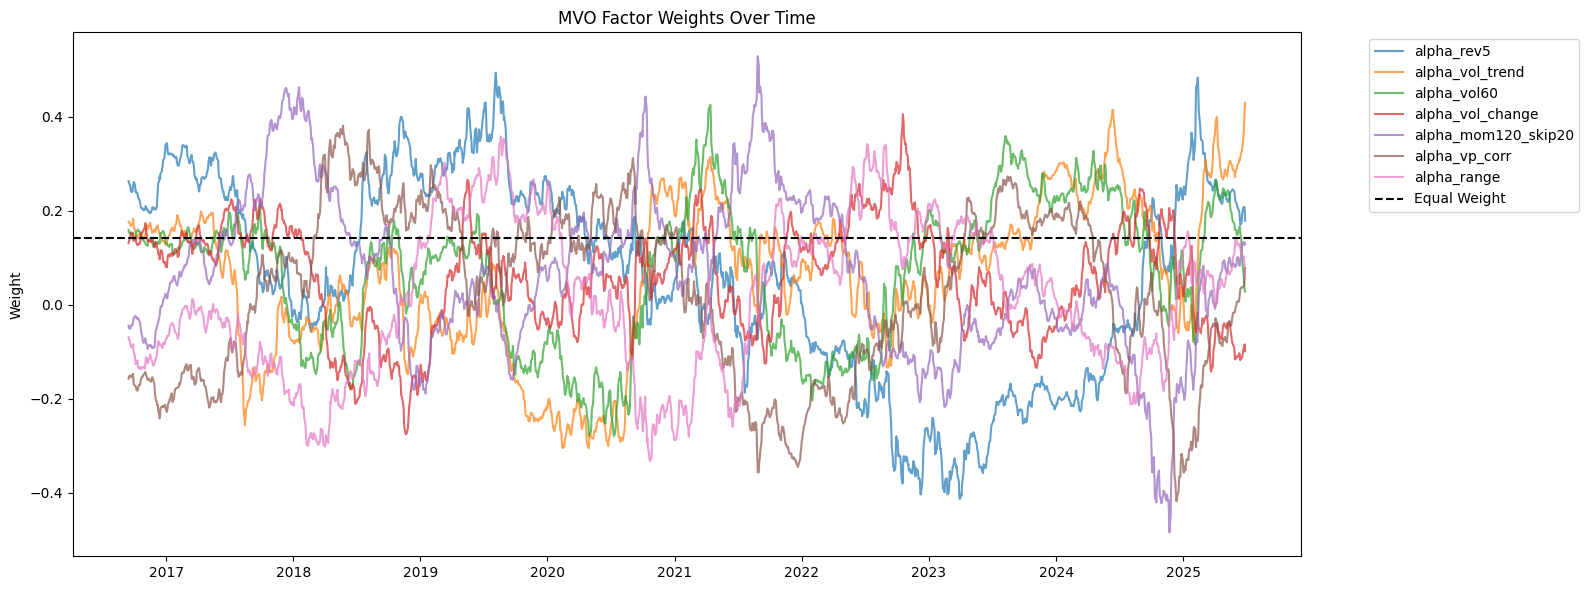

In [61]:
# 可视化：MVO权重随时间的变化
fig, ax = plt.subplots(figsize=(16, 6))
for col in alpha_cols:
    ax.plot(mvo_weights_df['Date'], mvo_weights_df[col], label=col, alpha=0.7)
ax.axhline(1/len(alpha_cols), color='black', linestyle='--', label='Equal Weight')
ax.set_title('MVO Factor Weights Over Time')
ax.set_ylabel('Weight')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../results/mvo_weights.png', dpi=150)
plt.show()

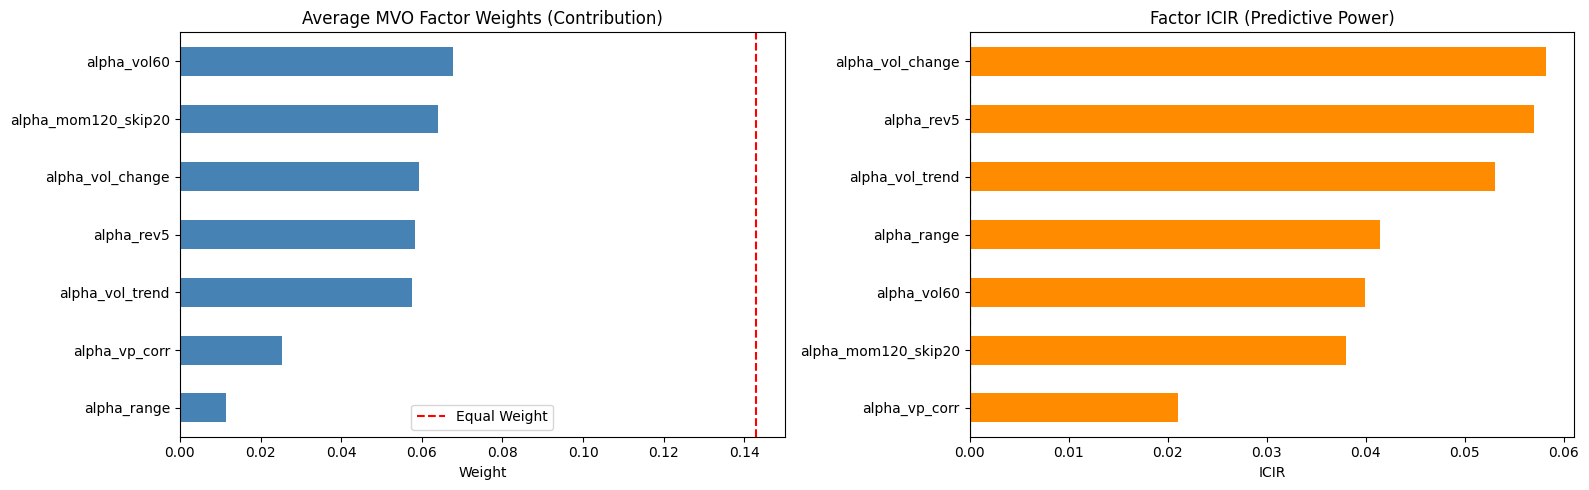

                     Avg MVO Weight    ICIR  IC Mean
alpha_vol60                  0.0679  0.0400   0.0059
alpha_mom120_skip20          0.0639  0.0380   0.0057
alpha_vol_change             0.0592  0.0582   0.0088
alpha_rev5                   0.0583  0.0570   0.0083
alpha_vol_trend              0.0575  0.0531   0.0080
alpha_vp_corr                0.0254  0.0211   0.0029
alpha_range                  0.0115  0.0415   0.0063


In [63]:
# Alpha Decomposition: Factor Contribution Analysis
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 左图：每个因子的平均MVO权重（贡献占比）
avg_weights = mvo_weights_df[alpha_cols].mean().sort_values(ascending=True)
avg_weights.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Average MVO Factor Weights (Contribution)')
axes[0].set_xlabel('Weight')
axes[0].axvline(1/len(alpha_cols), color='red', linestyle='--', label='Equal Weight')
axes[0].legend()

# 右图：每个因子的ICIR（预测能力）
icir_vals = pd.Series({
    col: ic_panel[col].mean() / ic_panel[col].std()
    for col in alpha_cols
}).sort_values(ascending=True)
icir_vals.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Factor ICIR (Predictive Power)')
axes[1].set_xlabel('ICIR')
axes[1].axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.savefig('../results/alpha_decomposition.png', dpi=150)
plt.show()

# 数字汇总
decomp = pd.DataFrame({
    'Avg MVO Weight': mvo_weights_df[alpha_cols].mean(),
    'ICIR': icir_vals,
    'IC Mean': ic_panel[alpha_cols].mean()
}).sort_values('Avg MVO Weight', ascending=False)
print(decomp.round(4))

# Part 3 - ML Modeling

In [32]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score

In [33]:
# 构造分类标签
stocks['Direction'] = (stocks['Return_next'] > 0).astype(int)

# 清理NaN（只保留特征和标签都完整的行）
model_cols = alpha_cols + ['Return_next', 'Direction', 'Date', 'Ticker']
df_clean = stocks[model_cols].dropna()
print(f"建模数据量: {df_clean.shape}")
print(f"日期范围: {df_clean['Date'].min()} ~ {df_clean['Date'].max()}")
print(f"正样本比例: {df_clean['Direction'].mean():.4f}")

建模数据量: (117184, 11)
日期范围: 2015-09-18 00:00:00 ~ 2025-06-27 00:00:00
正样本比例: 0.5597


Expanding Window的设置：<br>
前50%的数据作为最小训练集，之后每60个交易日（约3个月）往前推进一次，每次测试60天。这样大概会产生8-10个fold，既够评估稳定性，又不会让每个fold太小。

In [34]:
# Expanding Window 时间序列交叉验证
# 按日期排序，获取所有唯一日期
dates = sorted(df_clean['Date'].unique())
n_dates = len(dates)
print(f"总交易日数: {n_dates}")

# 设置参数
train_start_idx = 0                          # 训练起点：第一天
min_train_days = int(n_dates * 0.5)          # 最少用50%的数据做训练
test_window = 60                             # 每次测试60个交易日（约3个月）
step_size = 60                               # 每次向前滑动60天

# 构造fold
folds = []
current_train_end = min_train_days

while current_train_end + test_window <= n_dates:
    train_dates = dates[:current_train_end]
    test_dates = dates[current_train_end:current_train_end + test_window]
    folds.append((train_dates, test_dates))
    current_train_end += step_size

print(f"总共 {len(folds)} 个fold")
for i, (tr, te) in enumerate(folds):
    print(f"  Fold {i+1}: Train {tr[0].strftime('%Y-%m-%d')}~{tr[-1].strftime('%Y-%m-%d')} "
          f"({len(tr)}天) | Test {te[0].strftime('%Y-%m-%d')}~{te[-1].strftime('%Y-%m-%d')} ({len(te)}天)")

总交易日数: 2458
总共 20 个fold
  Fold 1: Train 2015-09-18~2020-08-05 (1229天) | Test 2020-08-06~2020-10-29 (60天)
  Fold 2: Train 2015-09-18~2020-10-29 (1289天) | Test 2020-10-30~2021-01-27 (60天)
  Fold 3: Train 2015-09-18~2021-01-27 (1349天) | Test 2021-01-28~2021-04-23 (60天)
  Fold 4: Train 2015-09-18~2021-04-23 (1409天) | Test 2021-04-26~2021-07-20 (60天)
  Fold 5: Train 2015-09-18~2021-07-20 (1469天) | Test 2021-07-21~2021-10-13 (60天)
  Fold 6: Train 2015-09-18~2021-10-13 (1529天) | Test 2021-10-14~2022-01-07 (60天)
  Fold 7: Train 2015-09-18~2022-01-07 (1589天) | Test 2022-01-10~2022-04-05 (60天)
  Fold 8: Train 2015-09-18~2022-04-05 (1649天) | Test 2022-04-06~2022-07-01 (60天)
  Fold 9: Train 2015-09-18~2022-07-01 (1709天) | Test 2022-07-05~2022-09-27 (60天)
  Fold 10: Train 2015-09-18~2022-09-27 (1769天) | Test 2022-09-28~2022-12-21 (60天)
  Fold 11: Train 2015-09-18~2022-12-21 (1829天) | Test 2022-12-22~2023-03-21 (60天)
  Fold 12: Train 2015-09-18~2023-03-21 (1889天) | Test 2023-03-22~2023-06-15 (60天)
 

这里用Ridge而不是普通Linear Regression，原因在于我们只有6个因子、上百万条数据，理论上过拟合风险不大。但加Ridge正则化（alpha=1.0）是行业标准做法，成本为零、收益为正。它会稍微压缩因子系数，让模型更稳健。

In [35]:
# 训练 Ridge Regression（回归）
reg_results = []       # 存每个fold的评估指标
reg_predictions = []   # 存所有fold的预测结果

for i, (train_dates, test_dates) in enumerate(folds):
    # 划分训练集和测试集
    train = df_clean[df_clean['Date'].isin(train_dates)]
    test  = df_clean[df_clean['Date'].isin(test_dates)]

    X_train = train[alpha_cols]
    y_train = train['Return_next']
    X_test  = test[alpha_cols]
    y_test  = test['Return_next']

    # Ridge Regression（L2正则化的线性回归）
    # alpha=1.0 是正则化强度，防止过拟合
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 评估指标
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)

    # 计算这个fold内每天的Rank IC
    test_with_pred = test[['Date', 'Ticker']].copy()
    test_with_pred['y_true'] = y_test.values
    test_with_pred['y_pred'] = y_pred

    daily_ic = test_with_pred.groupby('Date').apply(
        lambda x: spearmanr(x['y_pred'], x['y_true'])[0]
    )
    ic_mean = daily_ic.mean()
    ic_ir = daily_ic.mean() / daily_ic.std() if daily_ic.std() > 0 else 0

    reg_results.append({
        'Fold': i + 1,
        'MSE': mse, 'MAE': mae, 'R2': r2,
        'IC Mean': ic_mean, 'ICIR': ic_ir
    })
    reg_predictions.append(test_with_pred)

    print(f"Fold {i+1}: MSE={mse:.6f}, MAE={mae:.4f}, R2={r2:.4f}, "
          f"IC={ic_mean:.4f}, ICIR={ic_ir:.4f}")

# 打印最后一个fold的因子权重（系数）
print(f"\n最后一个Fold的Ridge系数:")
for name, coef in zip(alpha_cols, model.coef_):
    print(f"  {name}: {coef:.6f}")
print(f"  截距: {model.intercept_:.6f}")

Fold 1: MSE=0.002861, MAE=0.0393, R2=-0.0032, IC=-0.0756, ICIR=-0.5576
Fold 2: MSE=0.003770, MAE=0.0412, R2=-0.0672, IC=0.0220, ICIR=0.1834
Fold 3: MSE=0.003027, MAE=0.0419, R2=-0.0020, IC=-0.0112, ICIR=-0.0840
Fold 4: MSE=0.001721, MAE=0.0305, R2=-0.0154, IC=-0.0223, ICIR=-0.1567
Fold 5: MSE=0.001691, MAE=0.0289, R2=-0.0035, IC=0.0178, ICIR=0.1160
Fold 6: MSE=0.002827, MAE=0.0385, R2=-0.0036, IC=0.0099, ICIR=0.0747
Fold 7: MSE=0.004251, MAE=0.0492, R2=-0.0334, IC=-0.0193, ICIR=-0.1293
Fold 8: MSE=0.005338, MAE=0.0555, R2=-0.0965, IC=-0.0390, ICIR=-0.2808
Fold 9: MSE=0.003915, MAE=0.0484, R2=-0.0109, IC=0.0468, ICIR=0.3035
Fold 10: MSE=0.004311, MAE=0.0499, R2=-0.0001, IC=0.0302, ICIR=0.2080
Fold 11: MSE=0.002703, MAE=0.0388, R2=-0.0141, IC=-0.0263, ICIR=-0.2151
Fold 12: MSE=0.003177, MAE=0.0375, R2=-0.0334, IC=-0.0272, ICIR=-0.1613
Fold 13: MSE=0.002226, MAE=0.0340, R2=-0.0005, IC=0.0034, ICIR=0.0249
Fold 14: MSE=0.002512, MAE=0.0365, R2=0.0013, IC=0.0800, ICIR=0.5956
Fold 15: MSE=0.0

Ridge Regression 各Fold汇总
 Fold      MSE      MAE        R2   IC Mean      ICIR
    1 0.002861 0.039326 -0.003163 -0.075596 -0.557576
    2 0.003770 0.041223 -0.067227  0.021957  0.183415
    3 0.003027 0.041915 -0.001958 -0.011247 -0.083969
    4 0.001721 0.030476 -0.015361 -0.022266 -0.156739
    5 0.001691 0.028896 -0.003466  0.017793  0.116024
    6 0.002827 0.038459 -0.003592  0.009892  0.074663
    7 0.004251 0.049191 -0.033360 -0.019323 -0.129295
    8 0.005338 0.055450 -0.096501 -0.039033 -0.280830
    9 0.003915 0.048421 -0.010942  0.046769  0.303500
   10 0.004311 0.049938 -0.000099  0.030195  0.207959
   11 0.002703 0.038772 -0.014087 -0.026295 -0.215066
   12 0.003177 0.037501 -0.033442 -0.027198 -0.161277
   13 0.002226 0.034015 -0.000536  0.003449  0.024950
   14 0.002512 0.036528  0.001314  0.080000  0.595587
   15 0.003279 0.037367 -0.040499 -0.028154 -0.180847
   16 0.002764 0.036811 -0.003839 -0.004688 -0.035999
   17 0.003894 0.045158 -0.001614 -0.022438 -0.140824
   

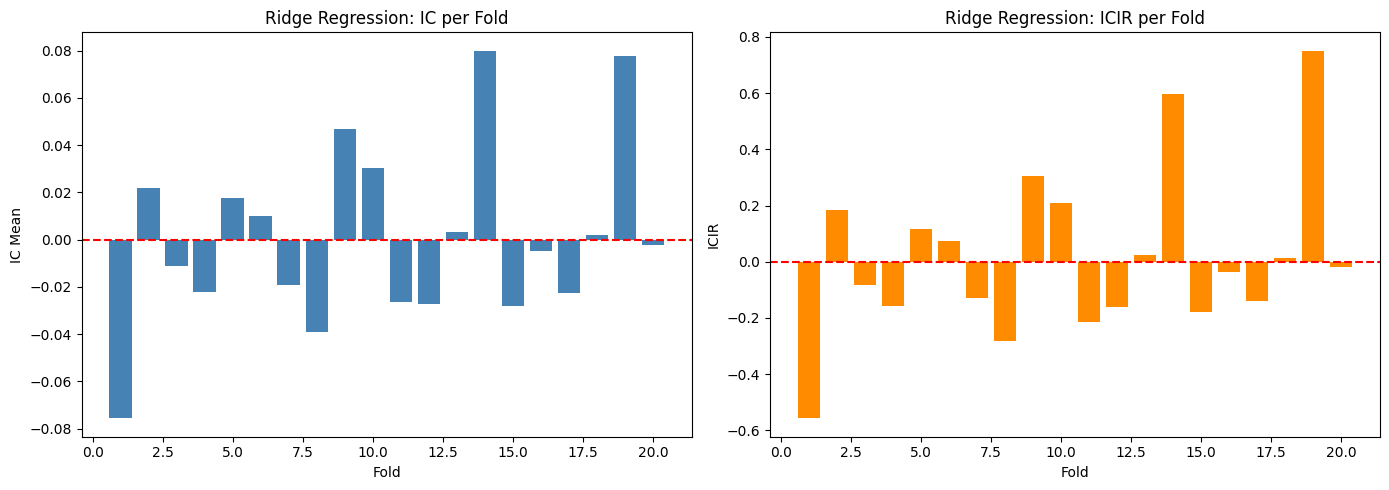

In [36]:
# Ridge Regression 汇总评估
reg_df = pd.DataFrame(reg_results)
print("=" * 60)
print("Ridge Regression 各Fold汇总")
print("=" * 60)
print(reg_df.to_string(index=False))
print(f"\n平均指标:")
print(f"  MSE:  {reg_df['MSE'].mean():.6f}")
print(f"  MAE:  {reg_df['MAE'].mean():.4f}")
print(f"  R2:   {reg_df['R2'].mean():.4f}")
print(f"  IC:   {reg_df['IC Mean'].mean():.4f}")
print(f"  ICIR: {reg_df['ICIR'].mean():.4f}")

# 可视化：每个fold的IC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(reg_df['Fold'], reg_df['IC Mean'], color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('IC Mean')
axes[0].set_title('Ridge Regression: IC per Fold')

axes[1].bar(reg_df['Fold'], reg_df['ICIR'], color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('ICIR')
axes[1].set_title('Ridge Regression: ICIR per Fold')

plt.tight_layout()
plt.savefig('../results/ridge_regression_ic.png', dpi=150)
plt.show()

In [38]:
# 训练 Logistic Regression（分类）
cls_results = []
cls_predictions = []

for i, (train_dates, test_dates) in enumerate(folds):
    train = df_clean[df_clean['Date'].isin(train_dates)]
    test  = df_clean[df_clean['Date'].isin(test_dates)]

    X_train = train[alpha_cols]
    y_train = train['Direction']
    X_test  = test[alpha_cols]
    y_test  = test['Direction']

    # Logistic Regression（L2正则化，C=1.0是正则化强度的倒数）
    model_cls = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs')
    model_cls.fit(X_train, y_train)

    y_pred_proba = model_cls.predict_proba(X_test)[:, 1]  # 预测"上涨"的概率
    y_pred_label = model_cls.predict(X_test)

    # 评估指标
    auc = roc_auc_score(y_test, y_pred_proba)
    logloss = log_loss(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred_label)

    # 用预测概率算Rank IC（概率越高越看好，和实际收益率的rank相关性）
    test_with_pred = test[['Date', 'Ticker', 'Return_next']].copy()
    test_with_pred['y_proba'] = y_pred_proba

    daily_ic = test_with_pred.groupby('Date').apply(
        lambda x: spearmanr(x['y_proba'], x['Return_next'])[0]
    )
    ic_mean = daily_ic.mean()
    ic_ir = daily_ic.mean() / daily_ic.std() if daily_ic.std() > 0 else 0

    cls_results.append({
        'Fold': i + 1,
        'AUC': auc, 'Log Loss': logloss, 'Accuracy': acc,
        'IC Mean': ic_mean, 'ICIR': ic_ir
    })
    cls_predictions.append(test_with_pred)

    print(f"Fold {i+1}: AUC={auc:.4f}, LogLoss={logloss:.4f}, "
          f"Acc={acc:.4f}, IC={ic_mean:.4f}, ICIR={ic_ir:.4f}")

print(f"\n最后一个Fold的Logistic系数:")
for name, coef in zip(alpha_cols, model_cls.coef_[0]):
    print(f"  {name}: {coef:.6f}")

Fold 1: AUC=0.4869, LogLoss=0.6919, Acc=0.5458, IC=-0.0547, ICIR=-0.4556
Fold 2: AUC=0.5071, LogLoss=0.6593, Acc=0.6466, IC=0.0107, ICIR=0.0785
Fold 3: AUC=0.5134, LogLoss=0.6813, Acc=0.5759, IC=0.0179, ICIR=0.1294
Fold 4: AUC=0.5181, LogLoss=0.6926, Acc=0.5413, IC=0.0342, ICIR=0.2732
Fold 5: AUC=0.5102, LogLoss=0.6934, Acc=0.5383, IC=0.0202, ICIR=0.1356
Fold 6: AUC=0.5095, LogLoss=0.6732, Acc=0.6023, IC=0.0358, ICIR=0.2240
Fold 7: AUC=0.4959, LogLoss=0.7209, Acc=0.4520, IC=-0.0284, ICIR=-0.1955
Fold 8: AUC=0.4937, LogLoss=0.7355, Acc=0.3943, IC=-0.0249, ICIR=-0.1888
Fold 9: AUC=0.5071, LogLoss=0.7079, Acc=0.4790, IC=0.0237, ICIR=0.1493
Fold 10: AUC=0.5145, LogLoss=0.6886, Acc=0.5490, IC=0.0283, ICIR=0.2367
Fold 11: AUC=0.4902, LogLoss=0.6837, Acc=0.5700, IC=-0.0265, ICIR=-0.1846
Fold 12: AUC=0.4996, LogLoss=0.6760, Acc=0.5997, IC=-0.0461, ICIR=-0.3788
Fold 13: AUC=0.5031, LogLoss=0.6911, Acc=0.5400, IC=0.0389, ICIR=0.2526
Fold 14: AUC=0.5211, LogLoss=0.6919, Acc=0.5353, IC=0.0600, ICI

Logistic Regression 各Fold汇总
 Fold      AUC  Log Loss  Accuracy   IC Mean      ICIR
    1 0.486877  0.691928  0.545826 -0.054740 -0.455570
    2 0.507073  0.659252  0.646599  0.010673  0.078520
    3 0.513371  0.681342  0.575850  0.017913  0.129351
    4 0.518088  0.692559  0.541343  0.034180  0.273153
    5 0.510235  0.693398  0.538333  0.020187  0.135635
    6 0.509484  0.673187  0.602333  0.035797  0.224046
    7 0.495889  0.720898  0.452000 -0.028429 -0.195464
    8 0.493703  0.735534  0.394333 -0.024933 -0.188806
    9 0.507085  0.707939  0.479000  0.023712  0.149259
   10 0.514509  0.688650  0.549000  0.028342  0.236748
   11 0.490217  0.683745  0.570000 -0.026473 -0.184626
   12 0.499603  0.676010  0.599667 -0.046114 -0.378824
   13 0.503129  0.691139  0.540000  0.038873  0.252589
   14 0.521108  0.691877  0.535333  0.060050  0.464459
   15 0.489718  0.668357  0.631333 -0.021828 -0.164961
   16 0.487681  0.699552  0.509667 -0.038182 -0.397277
   17 0.491485  0.689706  0.546333 -0

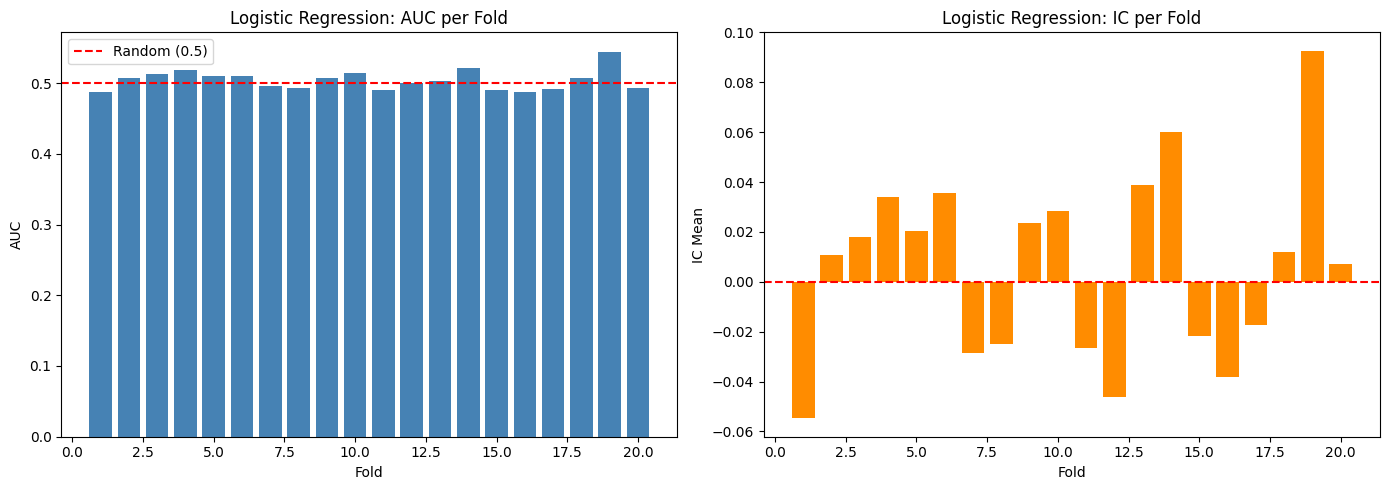

In [39]:
# Logistic Regression 汇总评估
cls_df = pd.DataFrame(cls_results)
print("=" * 60)
print("Logistic Regression 各Fold汇总")
print("=" * 60)
print(cls_df.to_string(index=False))
print(f"\n平均指标:")
print(f"  AUC:      {cls_df['AUC'].mean():.4f}")
print(f"  Log Loss: {cls_df['Log Loss'].mean():.4f}")
print(f"  Accuracy: {cls_df['Accuracy'].mean():.4f}")
print(f"  IC:       {cls_df['IC Mean'].mean():.4f}")
print(f"  ICIR:     {cls_df['ICIR'].mean():.4f}")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cls_df['Fold'], cls_df['AUC'], color='steelblue')
axes[0].axhline(0.5, color='red', linestyle='--', label='Random (0.5)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('AUC')
axes[0].set_title('Logistic Regression: AUC per Fold')
axes[0].legend()

axes[1].bar(cls_df['Fold'], cls_df['IC Mean'], color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('IC Mean')
axes[1].set_title('Logistic Regression: IC per Fold')

plt.tight_layout()
plt.savefig('../results/logistic_regression_ic.png', dpi=150)
plt.show()

In [40]:
# 两个模型对比
print("=" * 60)
print("模型对比总结")
print("=" * 60)
print(f"{'指标':<15} {'Ridge Regression':<20} {'Logistic Regression':<20}")
print("-" * 55)
print(f"{'IC Mean':<15} {reg_df['IC Mean'].mean():<20.4f} {cls_df['IC Mean'].mean():<20.4f}")
print(f"{'ICIR':<15} {reg_df['ICIR'].mean():<20.4f} {cls_df['ICIR'].mean():<20.4f}")
print(f"{'IC > 0 Folds':<15} {(reg_df['IC Mean'] > 0).sum()}/{len(reg_df):<17} "
      f"{(cls_df['IC Mean'] > 0).sum()}/{len(cls_df)}")

# Ridge 特有指标
print(f"\nRidge Regression:")
print(f"  平均 R2:  {reg_df['R2'].mean():.4f}")
print(f"  平均 MSE: {reg_df['MSE'].mean():.6f}")
print(f"  平均 MAE: {reg_df['MAE'].mean():.4f}")

# Logistic 特有指标
print(f"\nLogistic Regression:")
print(f"  平均 AUC:      {cls_df['AUC'].mean():.4f}")
print(f"  平均 Accuracy: {cls_df['Accuracy'].mean():.4f}")
print(f"  平均 Log Loss: {cls_df['Log Loss'].mean():.4f}")

模型对比总结
指标              Ridge Regression     Logistic Regression 
-------------------------------------------------------
IC Mean         0.0006               0.0062              
ICIR            0.0154               0.0360              
IC > 0 Folds    9/20                12/20

Ridge Regression:
  平均 R2:  -0.0167
  平均 MSE: 0.003410
  平均 MAE: 0.0415

Logistic Regression:
  平均 AUC:      0.5042
  平均 Accuracy: 0.5402
  平均 Log Loss: 0.6917


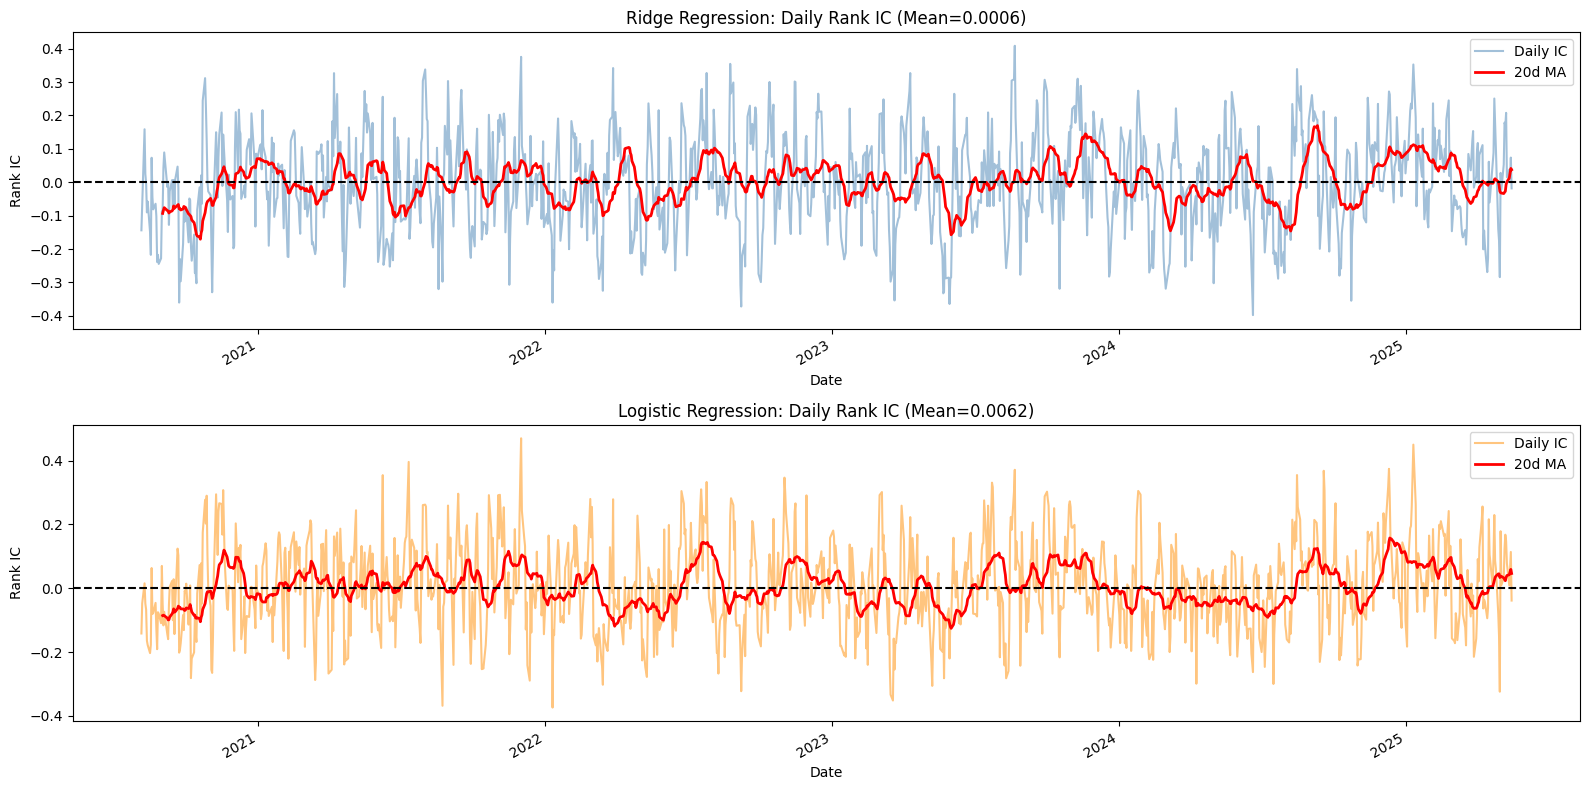

In [41]:
# IC时间序列图（合并所有fold的预测结果）
# Ridge的预测IC时间序列
all_reg_preds = pd.concat(reg_predictions)
reg_daily_ic = all_reg_preds.groupby('Date').apply(
    lambda x: spearmanr(x['y_pred'], x['y_true'])[0]
)

# Logistic的预测IC时间序列
all_cls_preds = pd.concat(cls_predictions)
cls_daily_ic = all_cls_preds.groupby('Date').apply(
    lambda x: spearmanr(x['y_proba'], x['Return_next'])[0]
)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

reg_daily_ic.plot(ax=axes[0], alpha=0.5, color='steelblue', label='Daily IC')
reg_daily_ic.rolling(20).mean().plot(ax=axes[0], color='red', linewidth=2, label='20d MA')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title(f'Ridge Regression: Daily Rank IC (Mean={reg_daily_ic.mean():.4f})')
axes[0].set_ylabel('Rank IC')
axes[0].legend()

cls_daily_ic.plot(ax=axes[1], alpha=0.5, color='darkorange', label='Daily IC')
cls_daily_ic.rolling(20).mean().plot(ax=axes[1], color='red', linewidth=2, label='20d MA')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title(f'Logistic Regression: Daily Rank IC (Mean={cls_daily_ic.mean():.4f})')
axes[1].set_ylabel('Rank IC')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/model_ic_timeseries.png', dpi=150)
plt.show()

# Part 4 - Portfolio Optimization

In [55]:
from scipy.optimize import minimize

# 用 stocks_with_mvo 作为数据源（已有MVO因子分）
portfolio_data_mvo = stocks_with_mvo[
    ['Date', 'Ticker', 'alpha_mvo_rolling', 'Return']
].dropna().copy()
portfolio_data_mvo = portfolio_data_mvo.rename(columns={'alpha_mvo_rolling': 'Score'})

# 宽表：日期 × 股票的日收益率（供MVO算协方差用）
return_pivot = stocks.pivot_table(index='Date', columns='Ticker', values='Return')

top_n        = 15      # 每次选Top 15只股票进MVO
lookback_cov = 120     # 用过去120天算协方差
risk_aversion = 2.0
rebalance_freq = 10

trade_dates      = sorted(portfolio_data_mvo['Date'].unique())
rebalance_dates  = trade_dates[::rebalance_freq]

# Benchmark：等权组合（只做多，不做空）
eq_daily = []
# 串联策略：MVO因子分选股 + MVO仓位优化
serial_daily = []

all_dates_list = sorted(return_pivot.index.tolist())

for rb_idx, rb_date in enumerate(rebalance_dates):
    day_data = portfolio_data_mvo[portfolio_data_mvo['Date'] == rb_date]
    if len(day_data) < 10:
        continue

    # 第一层结果：取综合分Top N只股票
    top_stocks = day_data.nlargest(top_n, 'Score')['Ticker'].tolist()

    # 等权benchmark权重
    eq_weights = pd.Series(1/len(top_stocks), index=top_stocks)

    # 第二层MVO：对Top N股票做仓位优化
    past_dates = [d for d in all_dates_list if d < rb_date][-lookback_cov:]
    cov_data   = return_pivot.loc[
        return_pivot.index.isin(past_dates), top_stocks
    ].dropna(axis=1)
    valid_stocks = cov_data.columns.tolist()

    if len(valid_stocks) < 5:
        mvo_weights = eq_weights.reindex(valid_stocks).fillna(1/len(valid_stocks))
    else:
        mu    = day_data[day_data['Ticker'].isin(valid_stocks)].set_index('Ticker')['Score']
        mu    = mu.reindex(valid_stocks).fillna(0).values
        Sigma = cov_data.cov().values + 0.001 * np.eye(len(valid_stocks))
        n     = len(valid_stocks)

        def neg_utility(w):
            return -(w @ mu - risk_aversion/2 * w @ Sigma @ w)

        res = minimize(neg_utility,
                       np.ones(n)/n,
                       method='SLSQP',
                       bounds=[(0, 0.20)]*n,
                       constraints={'type':'eq','fun': lambda w: w.sum()-1},
                       options={'ftol':1e-9,'maxiter':500})

        w = res.x if res.success else np.ones(n)/n
        w = np.clip(w, 0, None); w /= w.sum()
        mvo_weights = pd.Series(w, index=valid_stocks)

    # 持仓期收益
    if rb_idx + 1 < len(rebalance_dates):
        next_rb    = rebalance_dates[rb_idx + 1]
        hold_dates = [d for d in trade_dates if rb_date < d <= next_rb]
    else:
        hold_dates = [d for d in trade_dates if d > rb_date]

    for hd in hold_dates:
        if hd not in return_pivot.index:
            continue
        day_rets = return_pivot.loc[hd]

        serial_ret = sum(mvo_weights.get(t, 0) * day_rets.get(t, 0)
                         for t in valid_stocks)
        eq_ret     = day_rets.reindex(top_stocks).mean()

        serial_daily.append({'Date': hd, 'Return': serial_ret})
        eq_daily.append(   {'Date': hd, 'Return': eq_ret})

serial_df = pd.DataFrame(serial_daily).groupby('Date').mean().reset_index()
eq_df     = pd.DataFrame(eq_daily).groupby('Date').mean().reset_index()
print(f"回测完成，共 {len(serial_df)} 个交易日")

回测完成，共 2207 个交易日


# Part 5 - Performance Evaluation

MVO Factor Score + MVO Weights (Serial) | 年化:+38.45%  Sharpe:1.159  MaxDD:-35.20%
Equal Weight Benchmark (Top 15) | 年化:+33.66%  Sharpe:1.064  MaxDD:-37.55%
Market Equal Weight            | 年化:+27.67%  Sharpe:0.887  MaxDD:-35.93%


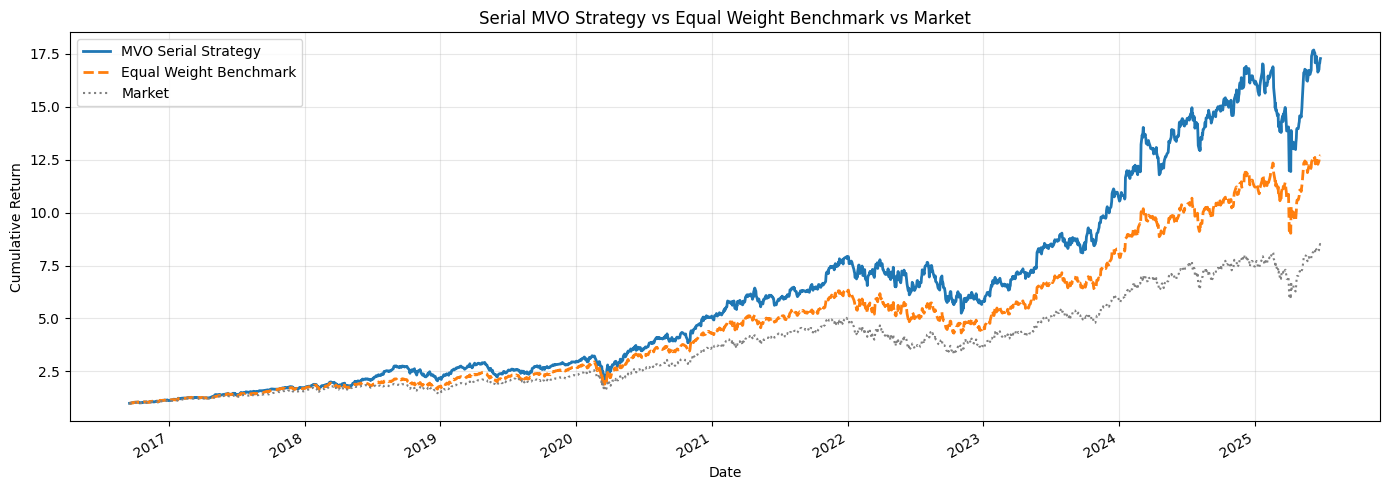

In [57]:
# 绩效对比
market_daily = stocks.groupby('Date')['Return'].mean().reset_index()
market_daily.columns = ['Date', 'Market_Return']

def calc_perf(ret_col, name):
    r = ret_col.dropna()
    total  = (1 + r).prod() - 1
    ann    = (1 + total) ** (252/len(r)) - 1
    sharpe = (ann - 0.04) / (r.std() * np.sqrt(252))
    cum    = (1 + r).cumprod()
    mdd    = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f"{name:30s} | 年化:{ann:+.2%}  Sharpe:{sharpe:.3f}  MaxDD:{mdd:.2%}")

print("="*75)
calc_perf(serial_df['Return'], "MVO Factor Score + MVO Weights (Serial)")
calc_perf(eq_df['Return'],     "Equal Weight Benchmark (Top 15)")
mkt = market_daily[market_daily['Date'].isin(serial_df['Date'])]['Market_Return']
calc_perf(mkt.reset_index(drop=True), "Market Equal Weight")
print("="*75)

# 累计收益曲线
fig, ax = plt.subplots(figsize=(14, 5))
(1 + serial_df.set_index('Date')['Return']).cumprod().plot(
    ax=ax, label='MVO Serial Strategy', linewidth=2)
(1 + eq_df.set_index('Date')['Return']).cumprod().plot(
    ax=ax, label='Equal Weight Benchmark', linewidth=2, linestyle='--')
mkt2 = market_daily[market_daily['Date'].isin(serial_df['Date'])].set_index('Date')
(1 + mkt2['Market_Return']).cumprod().plot(
    ax=ax, label='Market', linewidth=1.5, linestyle=':', color='gray')
ax.set_title('Serial MVO Strategy vs Equal Weight Benchmark vs Market')
ax.set_ylabel('Cumulative Return')
ax.legend(); 
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/serial_mvo_vs_benchmark.png', dpi=150)
plt.show()